In [8]:
from langgraph.graph import StateGraph,START, END
from typing import TypedDict, Literal

In [2]:
class EqState(TypedDict):
    a: int
    b: int
    c: int
    equation: str
    dis: float
    roots: str 

In [3]:
def show_equation(state: EqState):
    equation = f"{state['a']}X^2 + {state['b']}X + {state['c']}"
    
    return {"equation": equation}

def discriminant(state: EqState):
    dis = state['b']**2 - (4*state['a']*state['c'])
    
    return {'dis':dis}

In [5]:
def real(state: EqState):
    dis = state['dis']
    root_1 = (-state['b']+(dis**0.5))/2*state['a']
    root_2 = (-state['b']-(dis**0.5))/2*state['a']
    
    roots = f"The real roots are {root_1} & {root_2}"
    
    return {'roots':roots}

    

In [6]:
def equal(state: EqState):
    dis = state['dis']
    root_1 = (-state['b']+(dis**0.5))/2*state['a']
    root_2 = (-state['b']-(dis**0.5))/2*state['a']
    
    roots = f"The repeatative root is {root_1}"
    
    return {'roots':roots}

    

In [7]:
def im(state: EqState):
    
    roots = f"The equation has imaginary roots"
    
    return {'roots':roots}

    

In [13]:
def check_condition(state: EqState) -> Literal['real', 'equal', 'imaginary']:
    dis = state['dis']
    if dis>0:
        return 'real'
    elif dis==0:
        return "equal"
    else:
        return "imaginary"
    

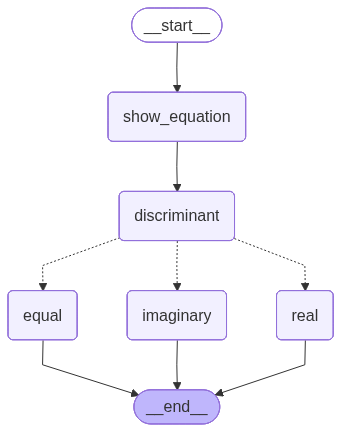

In [14]:
graph = StateGraph(EqState)

graph.add_node("show_equation", show_equation)
graph.add_node("discriminant", discriminant)
graph.add_node("real", real)
graph.add_node("equal", equal)
graph.add_node("imaginary", im)


graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "discriminant")
graph.add_conditional_edges("discriminant", check_condition)
graph.add_edge("real", END)
graph.add_edge("equal", END)
graph.add_edge("imaginary", END)


graph.compile()

In [19]:
workflow = graph.compile()

initial_state = {
    "a" : 2,
    "b" : 7,
    "c" : 5
}

final_state = workflow.invoke(initial_state)

In [20]:
final_state

{'a': 2,
 'b': 7,
 'c': 5,
 'equation': '2X^2 + 7X + 5',
 'dis': 9,
 'roots': 'The real roots are -4.0 & -10.0'}